## old stuff

In [ ]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from sklearn.model_selection import train_test_split
import os
import torch
import transformers
from datasets import load_dataset, Dataset
from huggingface_hub import notebook_login
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Trainer, TrainingArguments
import bitsandbytes as bnb
import re
import random
import sys

In [ ]:
print(f"Python version: {sys.version}")
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
Torch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: Tesla T4


In [ ]:
# Step 1: Load the CSV file
df = pd.read_csv('/content/tryhardguides_strands.csv')

print("DF shape:", df.shape)
print(df.head())

DF shape: (584, 7)
                                               title  \
0  NYT Strands #587 October 11, 2025 Answers (10/...   
1  NYT Strands #586 October 10, 2025 Answers (10/...   
2  NYT Strands #585 October 9, 2025 Answers (10/9...   
3  NYT Strands #584 October 8, 2025 Answers (10/8...   
4  NYT Strands #583 October 7, 2025 Answers (10/7...   

                                                 url  \
0  https://tryhardguides.com/nyt-strands-answers-...   
1  https://tryhardguides.com/nyt-strands-answers-...   
2  https://tryhardguides.com/nyt-strands-answers-...   
3  https://tryhardguides.com/nyt-strands-answers-...   
4  https://tryhardguides.com/nyt-strands-answers-...   

                        date  \
0  2025-10-10T12:15:00-07:00   
1  2025-10-09T12:15:00-07:00   
2  2025-10-08T12:15:00-07:00   
3  2025-10-07T12:15:00-07:00   
4  2025-10-06T12:15:00-07:00   

                                          theme_line     spangram  \
0  Today’s theme is “That's branding”, which 

In [ ]:
# Step 2: Extract theme from theme_line using provided regex
def extract_theme(line):
    matches = re.findall(r'[“"]([^“”"]+)[”"]', line)
    return matches[0] if matches else line  # Return first match or original if no match

df["theme"] = df["theme_line"].apply(extract_theme)

In [ ]:
# Step 3: Make spangram lowercase
df["spangram"] = df["spangram"].astype(str).str.lower()

In [ ]:
# Step 4: Split words into a list and make lowercase
def parse_words(val):
    if pd.isna(val):
        return []
    val = str(val).strip()
    try:
        words = ast.literal_eval(val)
        return [str(w).strip().lower() for w in words if str(w).strip()]
    except:
        if ',' in val:
            return [w.strip().lower() for w in val.split(",") if w.strip()]
        return [w.strip().lower() for w in val.split() if w.strip()]

df["words_list"] = df["words"].apply(parse_words)

In [ ]:
# Step 5: Convert grid string to 8x6 matrix (8 rows, 6 columns)
def format_grid(grid_str):
    if len(grid_str) != 48:  # 8*6 = 48 characters
        return "Invalid grid length"
    rows = [grid_str[i:i+6] for i in range(0, 48, 6)]
    return "\n".join(" ".join(row) for row in rows)  # Format as 'I L O Y\nA T N E\nR D E M' etc.

df["grid_formatted"] = df["grid"].apply(format_grid)

In [ ]:
df.head()

,title,url,date,theme_line,spangram,words,grid,theme,words_list,grid_formatted
0,"NYT Strands #587 October 11, 2025 Answers (10/...",https://tryhardguides.com/nyt-strands-answers-...,2025-10-10T12:15:00-07:00,"Today’s theme is “That's branding”, which is a...",iconiclogos,"APPLE, ARCHES, BULLSEYE, PEACOCK, SHELL, SWOOSH",ICONSHPEAIELOCKCSLACELHWPPLOSOEHGYSOSCOEELARSBUL,That's branding,"[apple, arches, bullseye, peacock, shell, swoosh]",I C O N S H\nP E A I E L\nO C K C S L\nA C E L...
1,"NYT Strands #586 October 10, 2025 Answers (10/...",https://tryhardguides.com/nyt-strands-answers-...,2025-10-09T12:15:00-07:00,"Today’s theme is “I'm a ladle hungry”, which i...",onepot,"CHILI, GOULASH, GUMBO, JAMBALAYA, RAGOUT, STEW...",RAGOUTWETGOBONESUMLALPOTUSAAYAOHBCHIGJAMILTAGINE,I'm a ladle hungry,"[chili, goulash, gumbo, jambalaya, ragout, ste...",R A G O U T\nW E T G O B\nO N E S U M\nL A L P...
2,"NYT Strands #585 October 9, 2025 Answers (10/9...",https://tryhardguides.com/nyt-strands-answers-...,2025-10-08T12:15:00-07:00,"Today’s theme is “Just in case”, which is a re...",packitup,"CHARGER, CLOTHES, HEADPHONES, LAPTOP, TOILETRIES",OTPLITLHUETOCEATERSPLISITPKADPOCCEHHHARAONREGPSE,Just in case,"[charger, clothes, headphones, laptop, toiletr...",O T P L I T\nL H U E T O\nC E A T E R\nS P L I...
3,"NYT Strands #584 October 8, 2025 Answers (10/8...",https://tryhardguides.com/nyt-strands-answers-...,2025-10-07T12:15:00-07:00,"Today’s theme is “Now, hear this!”, which is a...",soundcheck,"BASS, FEEDBACK, MIDRANGE, REVERB, TREBLE, VOLUME",FESOBREDIMUEBADRNVCKADREEGNCUESABHLMSCEVOLKTREBE,"Now, hear this!","[bass, feedback, midrange, reverb, treble, vol...",F E S O B R\nE D I M U E\nB A D R N V\nC K A D...
4,"NYT Strands #583 October 7, 2025 Answers (10/7...",https://tryhardguides.com/nyt-strands-answers-...,2025-10-06T12:15:00-07:00,"Today’s theme is “Unusual companions”, which i...",exoticpet,"AXOLOTL, CHINCHILLA, GECKO, PARROT, PYTHON, SKUNK",NIHETOCCPAXLHIACNOLLIOLTKEGTHPOCOTARNUSXYRKKEPTO,Unusual companions,"[axolotl, chinchilla, gecko, parrot, python, s...",N I H E T O\nC C P A X L\nH I A C N O\nL L I O...


In [ ]:
# Step 6: Log entries with empty word lists for debugging
empty_words = df[df["words_list"].apply(len) == 0]
print(f"Entries with empty word lists: {len(empty_words)}")
if len(empty_words) > 0:
    print("Empty word entries:", empty_words[["theme", "spangram", "words"]].to_dict('records'))

Entries with empty word lists: 0


In [ ]:
# Step 7: Basic EDA
print("Number of unique themes:", df['theme'].nunique())
print("Number of unique spangrams:", df['spangram'].nunique())

Number of unique themes: 581
Number of unique spangrams: 571


In [ ]:
# Step 8: Create JSON file with instruction-response pairs
dataset = []
missing_words = []
for idx, row in df.iterrows():
    theme = row["theme"]
    spangram = row["spangram"]
    words = row["words_list"]
    grid = row["grid_formatted"]

    if not words or len(words) == 0:
        missing_words.append({'theme': theme, 'spangram': spangram, 'index': idx, 'raw_words': row["words"]})
        continue

    words_str = ', '.join(words)

    instruction = f"""You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: '{theme}'

Grid:
{grid}"""

    response = f"Words: {words_str}; Spangram: {spangram}"

    dataset.append({
        "instruction": instruction,
        "response": response
    })

In [ ]:
# Log missing words
if missing_words:
    print("Entries with missing words:", missing_words)

In [ ]:
# Split into train (80%) and eval (20%)
train_data, eval_data = train_test_split(dataset, test_size=0.2, random_state=42)

In [ ]:
# Save to JSON files
with open('strands_train.json', 'w') as f:
    json.dump(train_data, f, indent=4)
with open('strands_eval.json', 'w') as f:
    json.dump(eval_data, f, indent=4)
print("JSON files created: strands_train.json and strands_eval.json")

JSON files created: strands_train.json and strands_eval.json


In [ ]:
import subprocess
import pkg_resources
import sys

/tmp/ipython-input-2985542403.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
# Verify transformers version
print(f"Transformers version: {pkg_resources.get_distribution('transformers').version}")
print(f"HuggingFace Hub version: {pkg_resources.get_distribution('huggingface_hub').version}")
print(f"Datasets version: {pkg_resources.get_distribution('datasets').version}")
import transformers
print(f"Transformers module path: {transformers.__file__}")

Transformers version: 4.57.0
HuggingFace Hub version: 0.35.3
Datasets version: 4.0.0
Transformers module path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
# Environment setup
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# Use Phi-3-mini-4k-instruct
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

In [ ]:
# Load tokenizer
def load_tokenizer(model_name):
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            trust_remote_code=False
        )
        print(f"Tokenizer loaded for {model_name}")
        # Manually set chat template if not loaded
        if tokenizer.chat_template is None:
            tokenizer.chat_template = "{{ bos_token }}{% for message in messages %}{% if (message['role'] == 'user') != (loop.index0 % 2 == 0) %}{{ raise_exception('Conversation roles must alternate user/assistant/user/assistant/...') }}{% endif %}{{ message['content'] }}{% if message['role'] == 'user' %}{{ ' <|end|>' }}{% endif %}{% endfor %}"
            print(f"Manually set chat template for {model_name}")
        return tokenizer
    except Exception as e:
        print(f"Tokenizer loading failed for {model_name}: {str(e)}. Trying legacy mode...")
        try:
            tokenizer = AutoTokenizer.from_pretrained(
                model_name,
                trust_remote_code=False,
                use_fast=False,
                legacy=True
            )
            print(f"Tokenizer loaded for {model_name} in legacy mode")
            if tokenizer.chat_template is None:
                tokenizer.chat_template = "{{ bos_token }}{% for message in messages %}{% if (message['role'] == 'user') != (loop.index0 % 2 == 0) %}{{ raise_exception('Conversation roles must alternate user/assistant/user/assistant/...') }}{% endif %}{{ message['content'] }}{% if message['role'] == 'user' %}{{ ' <|end|>' }}{% endif %}{% endfor %}"
                print(f"Manually set chat template for {model_name}")
            return tokenizer
        except Exception as e2:
            print(f"Legacy mode failed: {str(e2)}")
            raise Exception("Failed to load tokenizer. Check model availability or network.")

In [ ]:
tokenizer = load_tokenizer(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Tokenizer loaded for microsoft/Phi-3-mini-4k-instruct


In [ ]:
# Function to generate prediction
def generate_prediction(model, tokenizer, instruction):
    try:
        inputs = tokenizer(
            instruction,
            return_tensors="pt",
            max_length=256,  # Reduced for memory
            truncation=True,
            padding=True,
            return_attention_mask=True
        ).to("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Input IDs shape: {inputs['input_ids'].shape}")
        print(f"Attention mask shape: {inputs['attention_mask'].shape}")

        outputs = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=100,
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=3,
            use_cache=True
        )
        return tokenizer.decode(outputs[0], skip_special_tokens=True)
    except Exception as e:
        return f"Generation failed: {str(e)}"

In [ ]:
# Attempt quantized model loading
model = None
bnb_config = None
if bnb is not None:
    try:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            device_map="auto",
            trust_remote_code=False,
            quantization_config=bnb_config
        )
        print("Model loaded with 4-bit quantization.")
    except Exception as e:
        print(f"Quantized model loading failed: {str(e)}. Falling back to non-quantized model.")


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded with 4-bit quantization.


In [ ]:
# Align model and tokenizer tokens
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else None

# Enable gradient checkpointing to save memory
model.gradient_checkpointing_enable()

In [ ]:
# Load a random entry from the dataset for prediction
train_ds = load_dataset("json", data_files="/content/strands_train.json", split="train")
random_entry = random.choice(train_ds)
random_instruction = random_entry['instruction']
random_response = random_entry['response']
print("\nRandom entry for prediction:")
print(f"Instruction: {random_instruction}")
print(f"Expected Response: {random_response}")


Random entry for prediction:
Instruction: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'My cup of tea'

Grid:
O V M E R T
L E A P U M
N C S P N E
A O A E P G
N M L C M C
N I A H O A
C A E A M R
N I S I A D
Expected Response: Words: anise, cardamom, cinnamon, clove, nutmeg, pepper; Spangram: masalachai


In [ ]:
# Generate prediction *before* fine-tuning
print("\nPrediction BEFORE fine-tuning:")
pre_finetune_pred = generate_prediction(model, tokenizer, random_instruction)
print(pre_finetune_pred)


Prediction BEFORE fine-tuning:
Input IDs shape: torch.Size([1, 193])
Attention mask shape: torch.Size([1, 193])
You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'My cup of tea'

Grid:
O V M E R T
L E A P U M
N C S P N E
A O A E P G
N M L C M C
N I A H O A
C A E A M R
N I S I A D

Example format:
Words: 
Spangram word:

**Solution 1**

Writing down the words from the grid:
- OVEMERT
- LEAP
- PUMA
- NESP
- AE
- HOP
- CAR
- IS
- DA

Based on the theme "My cup (of tea)," the words that are related and form a connected path are


In [ ]:
print(model)

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear4bit(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear4bit(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=

In [ ]:
# Prepare for LoRA
if bnb is not None:
    model = prepare_model_for_kbit_training(model)

def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}")

lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules=["qkv_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
print_trainable_parameters(model)

trainable params: 12582912 || all params: 2021723136 || trainable%: 0.6223855173807538


In [ ]:
# Load dataset
eval_ds = load_dataset("json", data_files="/content/strands_eval.json", split="train")

# Preprocess function
def preprocess_function(examples):
    inputs = [instr + " " + resp + tokenizer.eos_token for instr, resp in zip(examples['instruction'], examples['response'])]
    model_inputs = tokenizer(inputs, max_length=256, truncation=True, padding="max_length")  # Reduced for memory
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    return model_inputs

tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_eval = eval_ds.map(preprocess_function, batched=True)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/467 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./strands_finetuned",
    per_device_train_batch_size=2,  # Reduced for memory
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    logging_dir="./logs", # Add logging directory
    logging_steps=10, # Log every 10 steps
    save_total_limit=2, # Limit the number of saved checkpoints
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
)

/tmp/ipython-input-2548635177.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.720900,0.762198
2,0.697800,0.770296
3,0.684000,0.780377
4,0.666100,0.786156
5,0.634600,0.816291
6,0.626300,0.841029
7,0.605400,0.856519
8,0.588700,0.888473
9,0.572000,0.915777
10,0.553200,0.923926


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

TrainOutput(global_step=590, training_loss=0.6337111117476124, metrics={'train_runtime': 3725.1847, 'train_samples_per_second': 1.254, 'train_steps_per_second': 0.158, 'total_flos': 2.679276421251072e+16, 'train_loss': 0.6337111117476124, 'epoch': 10.0})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save model
trainer.save_model("./strands_finetuned_final")

In [ ]:
print("\nRandom entry for prediction:")
print(f"Instruction: {random_instruction}")
print(f"Expected Response: {random_response}")


Random entry for prediction:
Instruction: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'My cup of tea'

Grid:
O V M E R T
L E A P U M
N C S P N E
A O A E P G
N M L C M C
N I A H O A
C A E A M R
N I S I A D
Expected Response: Words: anise, cardamom, cinnamon, clove, nutmeg, pepper; Spangram: masalachai


In [ ]:
# Generate prediction *after* fine-tuning
print("\nPrediction AFTER fine-tuning:")
post_finetune_pred = generate_prediction(model, tokenizer, random_instruction)
print(post_finetune_pred)


Prediction AFTER fine-tuning:
Input IDs shape: torch.Size([1, 193])
Attention mask shape: torch.Size([1, 193])
You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'My cup of tea'

Grid:
O V M E R T
L E A P U M
N C S P N E
A O A E P G
N M L C M C
N I A H O A
C A E A M R
N I S I A D Words:'acai, camomile, earl, green, matcha, peppermint, rooibos; Spanglegram: herbal


In [ ]:
# Copy the fine-tuned model directories to Google Drive
!cp -r ./strands_finetuned /content/drive/MyDrive/
!cp -r ./strands_finetuned_final /content/drive/MyDrive/

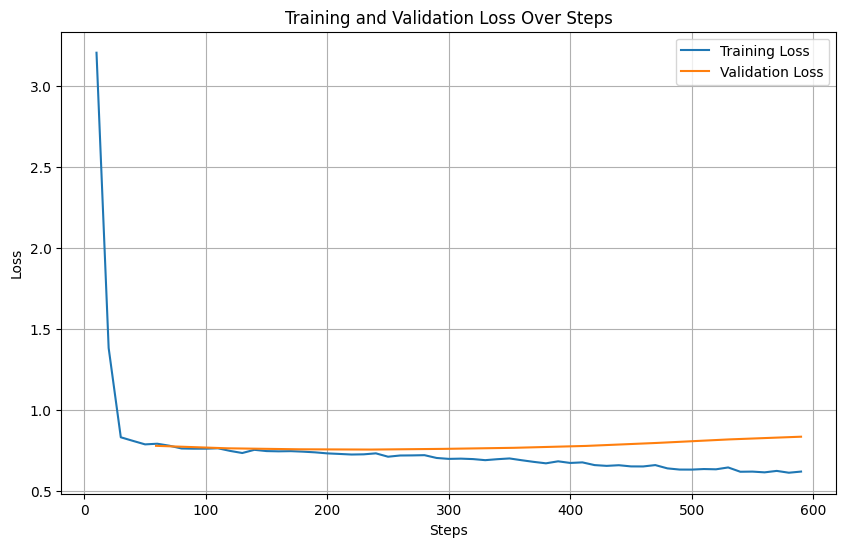

In [ ]:
# Load the trainer state file
trainer_state_path = "/content/strands_finetuned/checkpoint-590/trainer_state.json"

try:
    with open(trainer_state_path, "r") as f:
        trainer_state = json.load(f)

    log_history = trainer_state.get("log_history", [])

    # Extract loss data
    train_loss = []
    eval_loss = []
    steps = []
    eval_steps = []

    for log_entry in log_history:
        if "loss" in log_entry:
            train_loss.append(log_entry["loss"])
            steps.append(log_entry["step"])
        if "eval_loss" in log_entry:
            eval_loss.append(log_entry["eval_loss"])
            eval_steps.append(log_entry["step"])

    # Plot the losses
    plt.figure(figsize=(10, 6))
    plt.plot(steps, train_loss, label="Training Loss")
    plt.plot(eval_steps, eval_loss, label="Validation Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Steps")
    plt.legend()
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print(f"Error: {trainer_state_path} not found. Please make sure training has completed.")
except Exception as e:
    print(f"An error occurred while plotting the loss: {e}")

##

In [ ]:
!pip install -U bitsandbytes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from sklearn.model_selection import train_test_split
import os
import torch
import transformers
from datasets import load_dataset, Dataset
from huggingface_hub import notebook_login
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Trainer, TrainingArguments
import bitsandbytes as bnb
import re
import random
import sys

In [ ]:
# Environment setup
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Model and paths
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
SAVED_MODEL_PATH = "/content/drive/MyDrive/strands_finetuned_final" # This is the path to load from

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [ ]:
# Load dataset
train_ds = load_dataset("json", data_files="/content/strands_train.json", split="train")
eval_ds = load_dataset("json", data_files="/content/strands_eval.json", split="train")

# Print dataset samples for debugging
print("\nDataset sample (first 2 entries):")
for i in range(min(2, len(train_ds))):
    print(f"Entry {i}: instruction={train_ds[i]['instruction']}, response={train_ds[i]['response']}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]


Dataset sample (first 2 entries):
Entry 0: instruction=You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'It's been a while'

Grid:
E E C S E E
N V O S M L
G A N R A B
R E T H E N
M U N I O M
U O E T A E
S C N G G E
T E R R E T, response=Words: assemble, congregate, convene, gather, meet, muster; Spangram: reunion
Entry 1: instruction=You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarchi

In [ ]:
# Random entry for prediction
random_entry = random.choice(train_ds)
random_instruction = random_entry['instruction']
random_response = random_entry['response']
print("\nRandom entry for prediction:")
print(f"Instruction: {random_instruction}")
print(f"Expected Response: {random_response}")



Random entry for prediction:
Instruction: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'In glove'

Grid:
E D I M T H
L D N Y M U
G N I K B D
R I P A N I
O N H P O N
L M N R T C
A P A E I L
L I C U T E
Expected Response: Words: thumb, pointer, middle, ring, pinky, nail, palm, cuticle; Spangram: onhand


In [ ]:
# Function to generate prediction
def generate_prediction(model, tokenizer, instruction):
    try:
        # Apply chat template for consistency
        messages = [{"role": "user", "content": instruction}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            max_length=256,
            truncation=True,
            padding=True,
            return_attention_mask=True
        ).to("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Input IDs shape: {inputs['input_ids'].shape}")
        print(f"Attention mask shape: {inputs['attention_mask'].shape}")
        print(f"Input prompt: {prompt}")


        outputs = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=150,  # Increased for complete outputs
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=4,  # Relaxed to avoid repetition issues
            use_cache=True
        )
        return tokenizer.decode(outputs[0], skip_special_tokens=True)
    except Exception as e:
        return f"Generation failed: {str(e)}"


In [ ]:

# Load saved model with quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    trust_remote_code=False,
    quantization_config=bnb_config
)
model = prepare_model_for_kbit_training(model)


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:

# LoRA configuration
lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Expanded for Phi-3
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)


In [ ]:

def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}")

print_trainable_parameters(model)

trainable params: 6291456 || all params: 2015431680 || trainable%: 0.3121641910481431


In [ ]:

# Preprocess function
def preprocess_function(examples):
    inputs = [instr + " " + resp + tokenizer.eos_token for instr, resp in zip(examples['instruction'], examples['response'])]
    model_inputs = tokenizer(inputs, max_length=256, truncation=True, padding="max_length")
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    print("\nSample tokenized input:", tokenizer.decode(model_inputs["input_ids"][0], skip_special_tokens=False))
    return model_inputs

tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_eval = eval_ds.map(preprocess_function, batched=True)


Map:   0%|          | 0/467 [00:00<?, ? examples/s]


Sample tokenized input: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'It's been a while'

Grid:
E E C S E E
N V O S M L
G A N R A B
R E T H E N
M U N I O M
U O E T A E
S C N G G E
T E R R E T Words: assemble, congregate, convene, gather, meet, muster; Spangram: reunion<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|

Map:   0%|          | 0/117 [00:00<?, ? examples/s]


Sample tokenized input: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'I've got you under my skin'

Grid:
N B S G N L
I R O M A U
A T T E R C
S N H A N H
I A E L N S
T R O A I K
R L R G S D
E V I Y E N Words: brain, heart, kidneys, liver, lungs, stomach; Spangram: internalorgans<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|e

In [ ]:
# Check if Google Drive is mounted
if not os.path.exists('/content/drive'):
    print("Google Drive not mounted. Mounting now...")
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Google Drive already mounted.")

# Define the output directory in Google Drive
output_dir_drive = "/content/drive/MyDrive/strands_finetuned_continued"

# Create the output directory if it doesn't exist
os.makedirs(output_dir_drive, exist_ok=True)


Google Drive not mounted. Mounting now...
Mounted at /content/drive


In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir=output_dir_drive, # Save directly to Google Drive
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    logging_dir=os.path.join(output_dir_drive, "logs_continued"), # Save logs to Drive
    logging_steps=10,
    save_total_limit=2,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
)

/tmp/ipython-input-3939078515.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:



# Generate prediction *before* continued training
print("\nPrediction BEFORE continued fine-tuning:")
pre_finetune_pred = generate_prediction(model, tokenizer, random_instruction)
print(pre_finetune_pred)


Prediction BEFORE continued fine-tuning:
Input IDs shape: torch.Size([1, 195])
Attention mask shape: torch.Size([1, 195])
Input prompt: <|user|>
You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'In glove'

Grid:
E D I M T H
L D N Y M U
G N I K B D
R I P A N I
O N H P O N
L M N R T C
A P A E I L
L I C U T E<|end|>
<|assistant|>

You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching wor

In [ ]:

# Train for 10 more epochs
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.814800,0.797628
2,0.781000,0.777232
3,0.766000,0.769103
4,0.748800,0.765500
5,0.732300,0.764913
6,0.741400,0.764544
7,0.729100,0.765063
8,0.717800,0.769107
9,0.720700,0.770498
10,0.703800,0.776089


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

TrainOutput(global_step=590, training_loss=0.8173984640735691, metrics={'train_runtime': 3643.1408, 'train_samples_per_second': 1.282, 'train_steps_per_second': 0.162, 'total_flos': 2.6747634843648e+16, 'train_loss': 0.8173984640735691, 'epoch': 10.0})

In [ ]:
# Save the new model
trainer.save_model(os.path.join(output_dir_drive, "final")) # Save the final model


In [ ]:
# Plot loss graph
def plot_loss(trainer_state_path):
    try:
        with open(trainer_state_path, "r") as f:
            trainer_state = json.load(f)
        log_history = trainer_state.get("log_history", [])
        train_loss = []
        eval_loss = []
        steps = []
        eval_steps = []
        for log_entry in log_history:
            if "loss" in log_entry:
                train_loss.append(log_entry["loss"])
                steps.append(log_entry["step"])
            if "eval_loss" in log_entry:
                eval_loss.append(log_entry["eval_loss"])
                eval_steps.append(log_entry["step"])
        plt.figure(figsize=(10, 6))
        plt.plot(steps, train_loss, label="Training Loss")
        plt.plot(eval_steps, eval_loss, label="Validation Loss")
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Over Steps")
        plt.legend()
        plt.grid(True)
        plt.show()
    except FileNotFoundError:
        print(f"Error: {trainer_state_path} not found.")
    except Exception as e:
        print(f"An error occurred while plotting the loss: {e}")


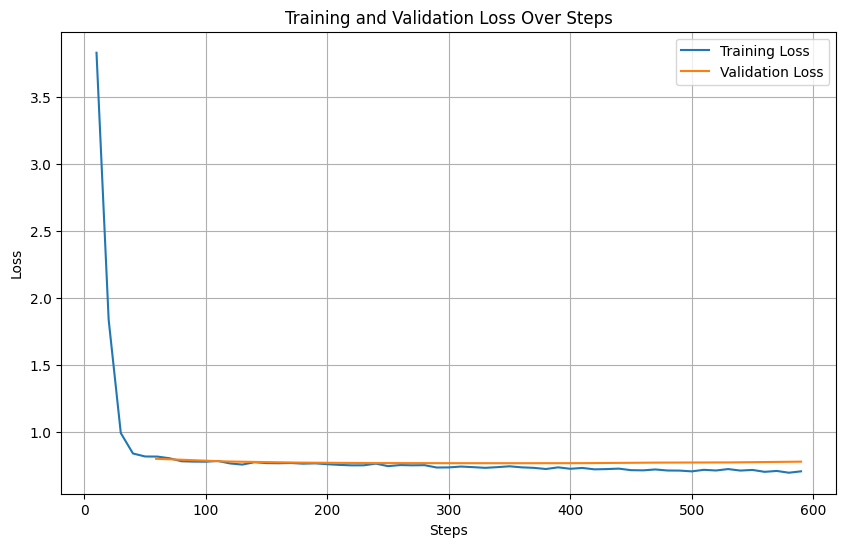

In [ ]:
# Plot from the latest checkpoint in Google Drive
latest_checkpoint = max([d for d in os.listdir(output_dir_drive) if d.startswith("checkpoint-")], key=lambda x: int(x.split('-')[1]))
trainer_state_path = os.path.join(output_dir_drive, latest_checkpoint, "trainer_state.json")
plot_loss(trainer_state_path)


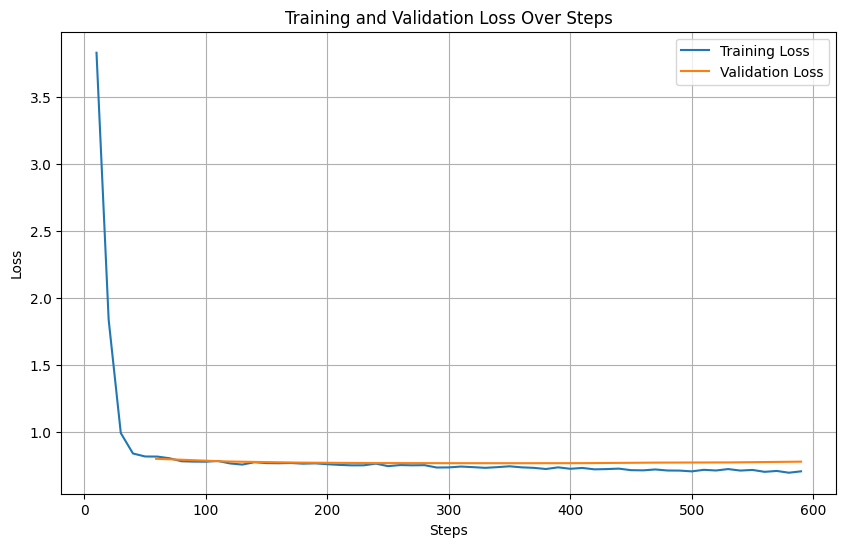

In [ ]:
# Plot from the latest checkpoint in Google Drive
latest_checkpoint = max([d for d in os.listdir(output_dir_drive) if d.startswith("checkpoint-")], key=lambda x: int(x.split('-')[1]))
trainer_state_path = os.path.join(output_dir_drive, latest_checkpoint, "trainer_state.json")
plot_loss(trainer_state_path)


In [ ]:
import os
import torch
import json
import matplotlib.pyplot as plt
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import load_dataset
import random

# Environment setup
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Model and paths
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
# Point to the directory containing the checkpoints
SAVED_MODEL_DIR = "/content/drive/MyDrive/strands_finetuned_continued"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load dataset
train_ds = load_dataset("json", data_files="/content/strands_train.json", split="train")
eval_ds = load_dataset("json", data_files="/content/strands_eval.json", split="train")

# Print dataset samples for debugging
print("\nDataset sample (first 2 entries):")
for i in range(min(2, len(train_ds))):
    print(f"Entry {i}: instruction={train_ds[i]['instruction']}, response={train_ds[i]['response']}")

# Function to generate prediction
def generate_prediction(model, tokenizer, instruction):
    try:
        # Apply chat template for consistency
        messages = [{"role": "user", "content": instruction}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            max_length=256,
            truncation=True,
            padding=True,
            return_attention_mask=True
        ).to("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Input IDs shape: {inputs['input_ids'].shape}")
        print(f"Attention mask shape: {inputs['attention_mask'].shape}")
        print(f"Input prompt: {prompt}")


        outputs = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=150,  # Increased for complete outputs
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=4,  # Relaxed to avoid repetition issues
            use_cache=True
        )
        return tokenizer.decode(outputs[0], skip_special_tokens=True)
    except Exception as e:
        return f"Generation failed: {str(e)}"

# Load saved model with quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Define the output directory in Google Drive
output_dir_drive = "/content/drive/MyDrive/strands_finetuned_continued_15"

# Create the output directory if it doesn't exist
os.makedirs(output_dir_drive, exist_ok=True)


Dataset sample (first 2 entries):
Entry 0: instruction=You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'It's been a while'

Grid:
E E C S E E
N V O S M L
G A N R A B
R E T H E N
M U N I O M
U O E T A E
S C N G G E
T E R R E T, response=Words: assemble, congregate, convene, gather, meet, muster; Spangram: reunion
Entry 1: instruction=You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarchi

In [ ]:
# Load model from the latest checkpoint if available, otherwise from scratch
latest_checkpoint = None
if os.path.exists(SAVED_MODEL_DIR):
    checkpoints = [d for d in os.listdir(SAVED_MODEL_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        latest_checkpoint = max([os.path.join(SAVED_MODEL_DIR, d) for d in checkpoints], key=os.path.getmtime)
        print(f"Loading model from latest checkpoint: {latest_checkpoint}")
        model = AutoModelForCausalLM.from_pretrained(
            latest_checkpoint,
            device_map="auto",
            trust_remote_code=False,
            quantization_config=bnb_config
        )
    else:
        print(f"No checkpoints found in {SAVED_MODEL_DIR}. Loading model from scratch.")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            device_map="auto",
            trust_remote_code=False,
            quantization_config=bnb_config
        )
else:
    print(f"Directory {SAVED_MODEL_DIR} not found. Loading model from scratch.")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map="auto",
        trust_remote_code=False,
        quantization_config=bnb_config
    )

model = prepare_model_for_kbit_training(model)

# LoRA configuration
lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Expanded for Phi-3
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)


Loading model from latest checkpoint: /content/drive/MyDrive/strands_finetuned_continued/checkpoint-590


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}")

print_trainable_parameters(model)

# Preprocess function
def preprocess_function(examples):
    inputs = [instr + " " + resp + tokenizer.eos_token for instr, resp in zip(examples['instruction'], examples['response'])]
    model_inputs = tokenizer(inputs, max_length=256, truncation=True, padding="max_length")
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    print("\nSample tokenized input:", tokenizer.decode(model_inputs["input_ids"][0], skip_special_tokens=False))
    return model_inputs

tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_eval = eval_ds.map(preprocess_function, batched=True)


trainable params: 6291456 || all params: 2015431680 || trainable%: 0.3121641910481431


Map:   0%|          | 0/467 [00:00<?, ? examples/s]


Sample tokenized input: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'It's been a while'

Grid:
E E C S E E
N V O S M L
G A N R A B
R E T H E N
M U N I O M
U O E T A E
S C N G G E
T E R R E T Words: assemble, congregate, convene, gather, meet, muster; Spangram: reunion<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|

Map:   0%|          | 0/117 [00:00<?, ? examples/s]


Sample tokenized input: You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'I've got you under my skin'

Grid:
N B S G N L
I R O M A U
A T T E R C
S N H A N H
I A E L N S
T R O A I K
R L R G S D
E V I Y E N Words: brain, heart, kidneys, liver, lungs, stomach; Spangram: internalorgans<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|e

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir=output_dir_drive, # Save directly to Google Drive
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=15, # Train for a total of 15 epochs
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    logging_dir=os.path.join(output_dir_drive, "logs_continued"), # Save logs to Drive
    logging_steps=10,
    save_total_limit=3, # Save more checkpoints if needed
    resume_from_checkpoint=latest_checkpoint # Resume from the latest checkpoint
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
)

/tmp/ipython-input-782005261.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Generate prediction *before* continued training
print("\nPrediction BEFORE continued fine-tuning:")
pre_finetune_pred = generate_prediction(model, tokenizer, random_instruction)
print(pre_finetune_pred)


Prediction BEFORE continued fine-tuning:
Input IDs shape: torch.Size([1, 195])
Attention mask shape: torch.Size([1, 195])
Input prompt: <|user|>
You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'In glove'

Grid:
E D I M T H
L D N Y M U
G N I K B D
R I P A N I
O N H P O N
L M N R T C
A P A E I L
L I C U T E<|end|>
<|assistant|>

You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching wor

In [ ]:

# Train for 5 more epochs
trainer.train(resume_from_checkpoint=latest_checkpoint)



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
11,0.702600,0.775124
12,0.699500,0.782612
13,0.686000,0.790541


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Epoch,Training Loss,Validation Loss
11,0.702600,0.775124
12,0.699500,0.782612
13,0.686000,0.790541
14,0.683500,0.803124
15,0.669400,0.806431


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=885, training_loss=0.22981457952725684, metrics={'train_runtime': 1819.0253, 'train_samples_per_second': 3.851, 'train_steps_per_second': 0.487, 'total_flos': 4.0121452265472e+16, 'train_loss': 0.22981457952725684, 'epoch': 15.0})

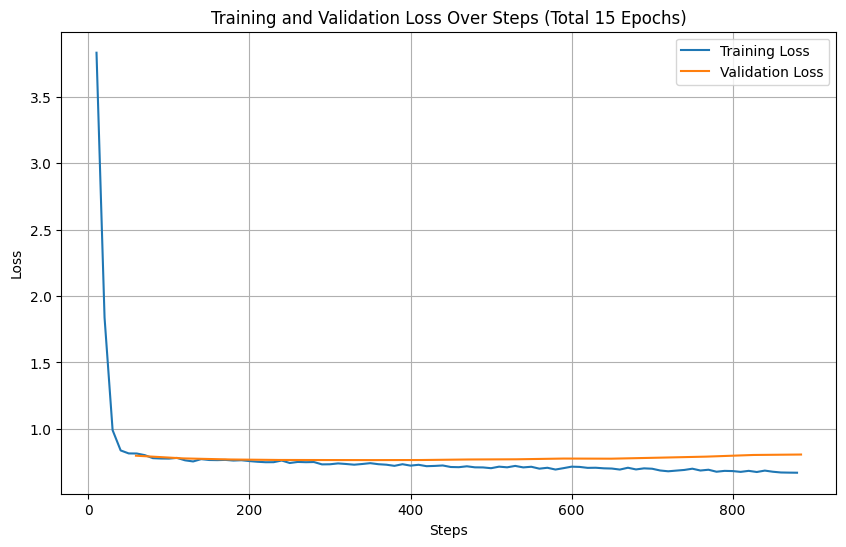

In [ ]:

# Save the new model
trainer.save_model(os.path.join(output_dir_drive, "final_15_epochs")) # Save the final model after 15 epochs

# The checkpoints are already being saved to Google Drive by the trainer

# Plot loss graph
def plot_loss(trainer_state_path):
    try:
        with open(trainer_state_path, "r") as f:
            trainer_state = json.load(f)
        log_history = trainer_state.get("log_history", [])
        train_loss = []
        eval_loss = []
        steps = []
        eval_steps = []
        for log_entry in log_history:
            if "loss" in log_entry:
                train_loss.append(log_entry["loss"])
                steps.append(log_entry["step"])
            if "eval_loss" in log_entry:
                eval_loss.append(log_entry["eval_loss"])
                eval_steps.append(log_entry["step"])
        plt.figure(figsize=(10, 6))
        plt.plot(steps, train_loss, label="Training Loss")
        plt.plot(eval_steps, eval_loss, label="Validation Loss")
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Over Steps (Total 15 Epochs)")
        plt.legend()
        plt.grid(True)
        plt.show()
    except FileNotFoundError:
        print(f"Error: {trainer_state_path} not found.")
    except Exception as e:
        print(f"An error occurred while plotting the loss: {e}")

# Plot from the latest checkpoint in Google Drive
latest_checkpoint_for_plot = max([d for d in os.listdir(output_dir_drive) if d.startswith("checkpoint-")], key=lambda x: int(x.split('-')[1]))
trainer_state_path = os.path.join(output_dir_drive, latest_checkpoint_for_plot, "trainer_state.json")
plot_loss(trainer_state_path)

In [ ]:









# Generate prediction *after* continued training
print("\nPrediction AFTER continued fine-tuning:")
post_finetune_pred = generate_prediction(model, tokenizer, random_instruction)
print(post_finetune_pred)

print("\nContinued fine-tuning completed!")


Prediction AFTER continued fine-tuning:
Input IDs shape: torch.Size([1, 195])
Attention mask shape: torch.Size([1, 195])
Input prompt: <|user|>
You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word that connects them all).
    The words must form connected paths in the grid. The theme may be indirect or metaphorical.
    Output only: Words: word1, word2, word3, ...; Spangram: spangram_word

Theme hint: 'In glove'

Grid:
E D I M T H
L D N Y M U
G N I K B D
R I P A N I
O N H P O N
L M N R T C
A P A E I L
L I C U T E<|end|>
<|assistant|>

You are an expert NYT Strands puzzle solver.
    Given the theme hint and an 8x6 letter grid, predict the list of words that can be connected in that grid only which are related to that theme (directly or indirectly) and the spangram (the overarching word

In [ ]:
# Load the model from the latest checkpoint for continued training
latest_checkpoint = None
SAVED_MODEL_DIR = "/content/drive/MyDrive/strands_finetuned_continued" # Directory of the previous training run
if os.path.exists(SAVED_MODEL_DIR):
    checkpoints = [d for d in os.listdir(SAVED_MODEL_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        latest_checkpoint = max([os.path.join(SAVED_MODEL_DIR, d) for d in checkpoints], key=os.path.getmtime)
        print(f"Loading model from latest checkpoint: {latest_checkpoint}")
        model = AutoModelForCausalLM.from_pretrained(
            latest_checkpoint,
            device_map="auto",
            trust_remote_code=False,
            quantization_config=bnb_config # Use the existing bnb_config
        )
    else:
        print(f"No checkpoints found in {SAVED_MODEL_DIR}. Cannot resume training.")
else:
    print(f"Directory {SAVED_MODEL_DIR} not found. Cannot resume training.")


if latest_checkpoint:
    model = prepare_model_for_kbit_training(model)

    # LoRA configuration (same as before)
    lora_config = LoraConfig(
        r=32,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )
    model = get_peft_model(model, lora_config)

    print_trainable_parameters(model) # Use the existing function

    # Define the output directory for the continued training in Google Drive
    output_dir_drive_continued = "/content/drive/MyDrive/strands_finetuned_continued_20_epochs"

    # Create the output directory if it doesn't exist
    os.makedirs(output_dir_drive_continued, exist_ok=True)

    # Training arguments for continued training
    training_args_continued = TrainingArguments(
        output_dir=output_dir_drive_continued, # Save directly to Google Drive
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4, # You might want to adjust this for continued training
        num_train_epochs=5, # Train for 5 more epochs
        weight_decay=0.01,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none",
        logging_dir=os.path.join(output_dir_drive_continued, "logs_continued"), # Save logs to Drive
        logging_steps=10,
        save_total_limit=2, # Save more checkpoints if needed
        resume_from_checkpoint=latest_checkpoint # Resume from the latest checkpoint
    )

    # Trainer for continued training
    trainer_continued = Trainer(
        model=model,
        args=training_args_continued,
        train_dataset=tokenized_train, # Use the existing tokenized datasets
        eval_dataset=tokenized_eval,
        tokenizer=tokenizer, # Use the existing tokenizer
    )

    # Generate prediction *before* continued training (using the loaded model)
    print("\nPrediction BEFORE continued fine-tuning:")
    pre_finetune_pred_continued = generate_prediction(model, tokenizer, random_instruction)
    print(pre_finetune_pred_continued)

    # Train for 5 more epochs
    trainer_continued.train(resume_from_checkpoint=latest_checkpoint)

    # Save the final model after the additional epochs
    trainer_continued.save_model(os.path.join(output_dir_drive_continued, "final_20_epochs"))

    # Plot combined loss graph
    def plot_combined_loss(trainer_state_paths):
        plt.figure(figsize=(10, 6))
        all_steps = []
        all_train_loss = []
        all_eval_loss = []
        all_eval_steps = []

        for trainer_state_path in trainer_state_paths:
            try:
                with open(trainer_state_path, "r") as f:
                    trainer_state = json.load(f)
                log_history = trainer_state.get("log_history", [])

                for log_entry in log_history:
                    if "loss" in log_entry:
                        all_train_loss.append(log_entry["loss"])
                        all_steps.append(log_entry["step"])
                    if "eval_loss" in log_entry:
                        all_eval_loss.append(log_entry["eval_loss"])
                        all_eval_steps.append(log_entry["step"])
            except FileNotFoundError:
                print(f"Warning: {trainer_state_path} not found.")
            except Exception as e:
                print(f"An error occurred while reading {trainer_state_path}: {e}")

        # Sort data by steps to ensure correct plotting order
        sorted_train_data = sorted(zip(all_steps, all_train_loss))
        sorted_eval_data = sorted(zip(all_eval_steps, all_eval_loss))

        if sorted_train_data:
            steps, train_loss = zip(*sorted_train_data)
            plt.plot(steps, train_loss, label="Training Loss")
        if sorted_eval_data:
            eval_steps, eval_loss = zip(*sorted_eval_data)
            plt.plot(eval_steps, eval_loss, label="Validation Loss")

        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Over Steps (Total 20 Epochs)")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Define paths to trainer_state.json for both training runs
    previous_trainer_state_path = os.path.join(SAVED_MODEL_DIR, "checkpoint-590", "trainer_state.json") # Assuming the last checkpoint from previous run was 590
    current_trainer_state_path = os.path.join(output_dir_drive_continued, trainer_continued.state.best_model_checkpoint.split('/')[-1], "trainer_state.json")


    # Plot from the latest checkpoint in Google Drive
    latest_checkpoint_for_plot = max([d for d in os.listdir(output_dir_drive_continued) if d.startswith("checkpoint-")], key=lambda x: int(x.split('-')[1]))
    current_trainer_state_path_for_plot = os.path.join(output_dir_drive_continued, latest_checkpoint_for_plot, "trainer_state.json")

    plot_combined_loss([previous_trainer_state_path, current_trainer_state_path_for_plot])


    # Generate prediction *after* continued training
    print("\nPrediction AFTER continued fine-tuning:")
    post_finetune_pred_continued = generate_prediction(model, tokenizer, random_instruction)
    print(post_finetune_pred_continued)

    print("\nContinued fine-tuning completed!")